## 1. Introduction: Hierarchical Composition

In this notebook, we merge our modular binary masks into a single **Categorical Master Mask**. 

**The Priority Hierarchy:**
1. **Class 3 (High Veg):** Highest priority. If a tree canopy exists, it is labeled as Class 3, regardless of what is underneath (roof or grass).
2. **Class 2 (Grassland):** Overwrites Built-up in specific edge cases, or acts as the primary green groundcover.
3. **Class 1 (Built-up):** Buildings and sealed surfaces.
4. **Class 0 (Background):** Any pixel not covered by the above datasets.

**Strategy:**
We iterate through the `train` and `val` folders, load the three binary TIFFs for each anchor UID, and apply the "painter's algorithm" (layering from lowest to highest priority) to create a single 4-class mask.

In [2]:
import os
import numpy as np
import geopandas as gpd
import rasterio
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# --- Directory Configuration ---
BASE_OUT = "../data/processed_modular"
META_DIR = f"{BASE_OUT}/metadata"

# Input Task Folders
TASKS = ["masks_builtup", "masks_grassland", "masks_highveg"]
# Output Folder for Multi-class labels
COMBINED_TASK = "masks_combined"

# Load anchors to get the universal file list
gdf_anchors = gpd.read_file(f"{META_DIR}/building_anchors_2000.gpkg")

## 2. Defining the Hierarchical Function

By using a function, we ensure that the same logic used to create training data can be reused later to merge predictions from three separate models.

In [3]:
def compose_hierarchical_mask(built_arr, grass_arr, highveg_arr):
    """
    Combines three binary masks into one categorical mask based on user-defined priority.
    Hierarchy (High to Low): HighVeg (3) > Grassland (2) > Built-up (1)
    """
    # Initialize background (Class 0)
    combined = np.zeros_like(built_arr, dtype=np.uint8)
    
    # 1. Apply Built-up (Class 1) - Lowest Priority
    combined[built_arr == 1] = 1
    
    # 2. Apply Grassland (Class 2) - Overwrites Built-up
    combined[grass_arr == 1] = 2
    
    # 3. Apply Higher Vegetation (Class 3) - Overwrites Everything
    combined[highveg_arr == 1] = 3
    
    return combined

## 3. Global Synthesis Loop

We loop through every anchor, locate the three binary TIFFs, and save the unified result.

In [4]:
for split in ['train', 'val']:
    os.makedirs(f"{BASE_OUT}/{split}/{COMBINED_TASK}", exist_ok=True)

print(f"Synthesizing combined masks for {len(gdf_anchors)} samples...")

for idx, row in tqdm(gdf_anchors.iterrows(), total=len(gdf_anchors)):
    uid, split = row['unique_id'], row['split']
    
    # Construct Paths
    path_built = f"{BASE_OUT}/{split}/masks_builtup/{uid}_mask.tif"
    path_grass = f"{BASE_OUT}/{split}/masks_grassland/{uid}_mask.tif"
    path_highveg = f"{BASE_OUT}/{split}/masks_highveg/{uid}_mask.tif"
    out_path = f"{BASE_OUT}/{split}/{COMBINED_TASK}/{uid}_mask.tif"
    
    if os.path.exists(out_path): continue
    
    try:
        # Read the three binary masks
        with rasterio.open(path_built) as s: m_built = s.read(1)
        with rasterio.open(path_grass) as s: m_grass = s.read(1)
        with rasterio.open(path_highveg) as s: m_highveg = s.read(1)
        
        # Combine using our priority logic
        final_mask = compose_hierarchical_mask(m_built, m_grass, m_highveg)
        
        # Save using metadata from highveg (they all share the same spatial profile)
        with rasterio.open(path_highveg) as src:
            meta = src.meta.copy()
            meta.update(dtype=rasterio.uint8, count=1)
            
            with rasterio.open(out_path, 'w', **meta) as dest:
                dest.write(final_mask, 1)
                
    except FileNotFoundError:
        # This handles cases where one mask might be missing for a specific UID
        continue

print("✅ Combined Multi-class masks generated successfully.")

Synthesizing combined masks for 2000 samples...


  0%|          | 0/2000 [00:00<?, ?it/s]

✅ Combined Multi-class masks generated successfully.


## 4. Final Sanity Check

We visualize a random sample to ensure the colors represent the correct hierarchy.

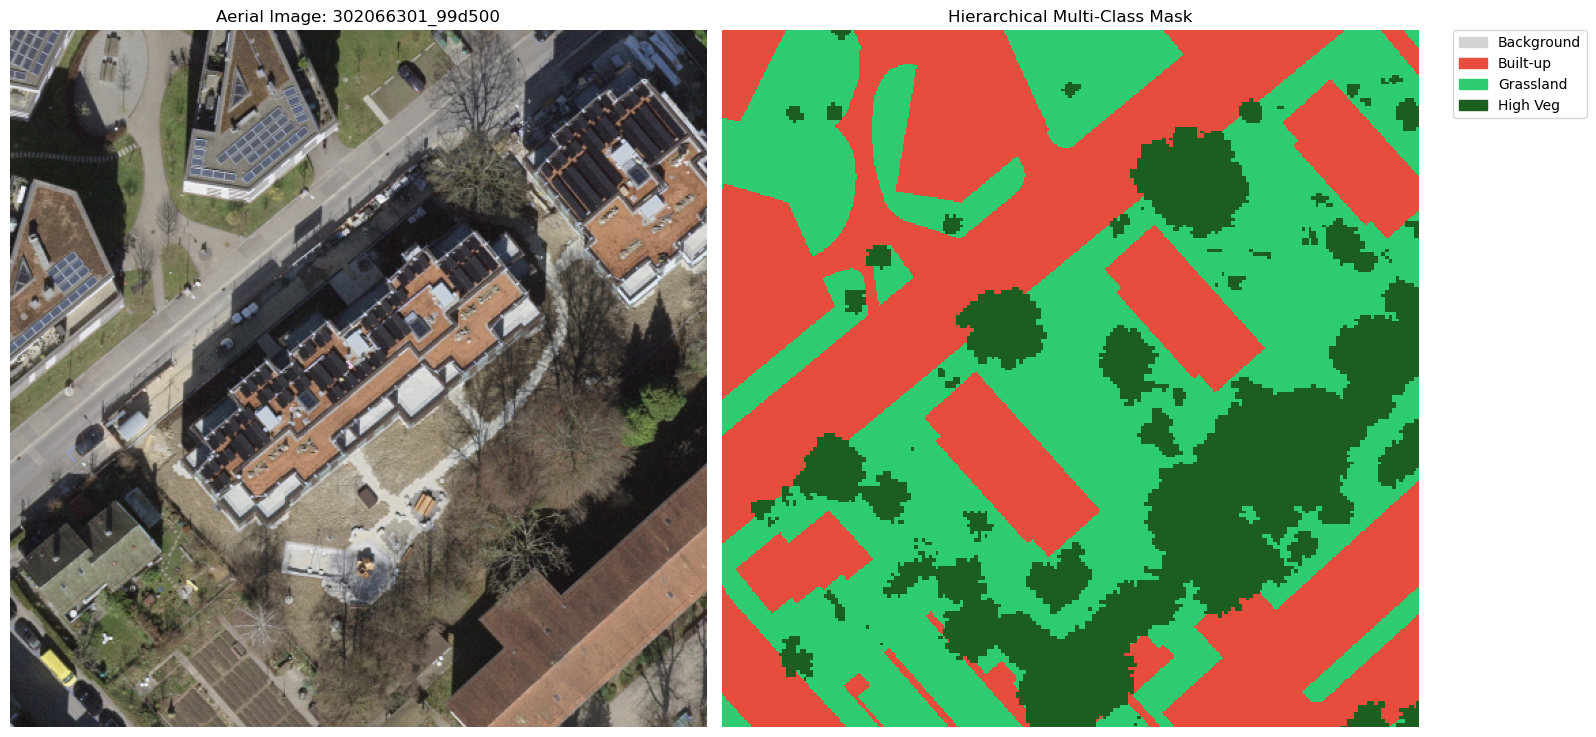

In [5]:
# Sample a random anchor
sample = gdf_anchors.sample(1).iloc[0]
uid, split = sample['unique_id'], sample['split']

mask_path = f"{BASE_OUT}/{split}/{COMBINED_TASK}/{uid}_mask.tif"
img_path = f"{BASE_OUT}/{split}/images/{uid}_swissimage.tif"

with rasterio.open(mask_path) as s: combined = s.read(1)
with rasterio.open(img_path) as s: img = s.read()[:3].transpose(1, 2, 0)

# Custom colormap: 0:Grey, 1:Red (Built), 2:LightGreen (Grass), 3:DarkGreen (Trees)
custom_cmap = ListedColormap(['#d3d3d3', '#e74c3c', '#2ecc71', '#1b5e20'])

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(img)
ax[0].set_title(f"Aerial Image: {uid}")
ax[0].axis('off')

im = ax[1].imshow(combined, cmap=custom_cmap, vmin=0, vmax=3, interpolation='nearest')
ax[1].set_title("Hierarchical Multi-Class Mask")
ax[1].axis('off')

# Add Legend
labels = {0: 'Background', 1: 'Built-up', 2: 'Grassland', 3: 'High Veg'}
patches = [mpatches.Patch(color=custom_cmap(i), label=labels[i]) for i in range(4)]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()